In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import csv
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
# إنشاء الملفات يلا ماكانوش باش ما يوقعش إيرور
os.makedirs('./Models', exist_ok=True)
os.makedirs('./History', exist_ok=True)

In [3]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, path='./Models/best_plant_resnet50.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

In [ ]:
# you can download the dataset from https://www.kaggle.com/datasets/emmarex/plantdisease
data_dir = r".\PlantVillage"

In [5]:
# إعداد الـ Transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# قراءة البيانات جوج مرات باش نعطيو لكل وحدة الـ Transform ديالها
train_dataset_full = datasets.ImageFolder(root=data_dir, transform=train_transform)
val_dataset_full = datasets.ImageFolder(root=data_dir, transform=val_transform)

In [6]:
# أخذ عينة عشوائية للتقسيم (80% تدريب، 20% تقييم)
indices = torch.randperm(len(train_dataset_full)).tolist()
train_size = int(0.8 * len(train_dataset_full))

# إنشاء المجموعات الصحيحة
train_data = torch.utils.data.Subset(train_dataset_full, indices[:train_size])
val_data = torch.utils.data.Subset(val_dataset_full, indices[train_size:])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

In [7]:
class_names = train_dataset_full.classes
print(f"Number of classes: {len(class_names)}")

Number of classes: 15


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(pretrained=True)

c:\Users\Demahom\anaconda3\envs\plant_env\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Demahom\anaconda3\envs\plant_env\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
# تجميد كل الطبقات
for param in model.parameters():
    param.requires_grad = False

In [10]:
# تغيير الطبقة الأخيرة
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

In [11]:
optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

In [12]:
csv_file = './History/training_history.csv'
with open(csv_file, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Epoch', 'Train Loss', 'Train Accuracy', 'Val Loss', 'Val Accuracy'])

In [13]:
num_epochs = 20
early_stopping = EarlyStopping(patience=3, path='./Models/best_plant_resnet50.pth')

In [14]:
for epoch in range(num_epochs):
    # مرحلة التدريب
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        train_bar.set_postfix(loss=loss.item())
        
    train_loss = running_loss / len(train_data)
    train_acc = 100 * correct / total

    # مرحلة التقييم
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
    with torch.no_grad():
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            val_bar.set_postfix(loss=loss.item())
            
    val_loss = val_loss / len(val_data)
    val_acc = 100 * val_correct / val_total
    
    # التسجيل فملف الـ CSV
    with open(csv_file, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([epoch+1, train_loss, train_acc, val_loss, val_acc])
        
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # توقف مبكر
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping triggered! Training stopped.")
        break

Epoch 1/20 [Val]: 100%|██████████| 129/129 [00:18<00:00,  7.16it/s, loss=1.14]


Train Loss: 1.9106 | Train Acc: 47.40% | Val Loss: 1.3309 | Val Acc: 68.53%


Epoch 2/20 [Val]: 100%|██████████| 129/129 [00:21<00:00,  6.00it/s, loss=0.836]


Train Loss: 1.2992 | Train Acc: 67.24% | Val Loss: 0.9957 | Val Acc: 74.13%


Epoch 3/20 [Val]: 100%|██████████| 129/129 [00:21<00:00,  6.09it/s, loss=0.719]


...

Train Loss: 0.5793 | Train Acc: 82.42% | Val Loss: 0.4344 | Val Acc: 87.14%


Epoch 19/20 [Val]: 100%|██████████| 129/129 [00:20<00:00,  6.20it/s, loss=0.338]


Train Loss: 0.5685 | Train Acc: 82.32% | Val Loss: 0.4182 | Val Acc: 87.19%


Epoch 20/20 [Val]: 100%|██████████| 129/129 [00:20<00:00,  6.30it/s, loss=0.345]

Train Loss: 0.5577 | Train Acc: 82.93% | Val Loss: 0.4322 | Val Acc: 86.34%


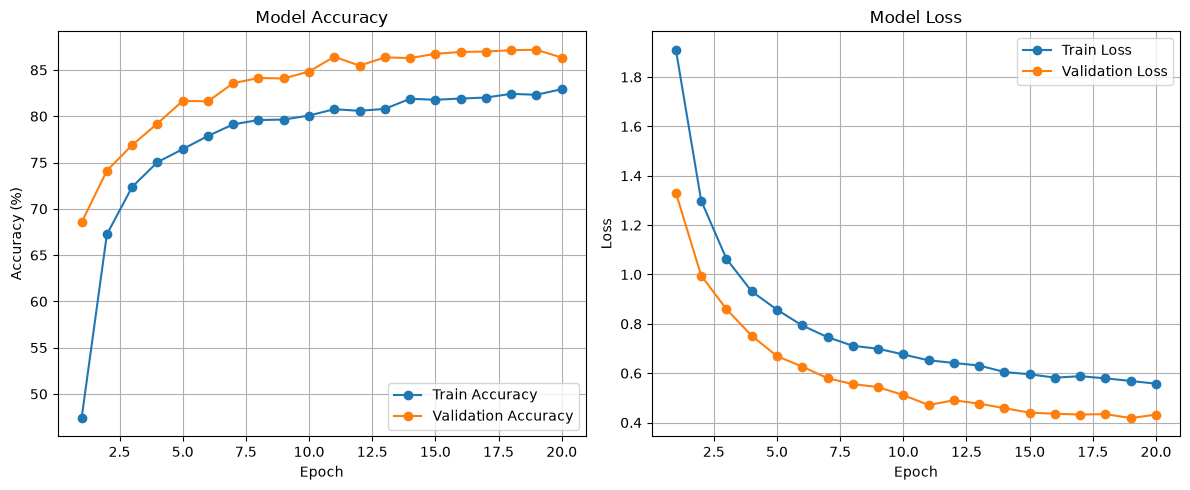

In [20]:
df = pd.read_csv('./History/training_history.csv')
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(df['Epoch'], df['Train Accuracy'], label='Train Accuracy', marker='o')
plt.plot(df['Epoch'], df['Val Accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(df['Epoch'], df['Train Loss'], label='Train Loss', marker='o')
plt.plot(df['Epoch'], df['Val Loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
model.load_state_dict(torch.load('./Models/best_plant_resnet50.pth'))
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [22]:

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader: 
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


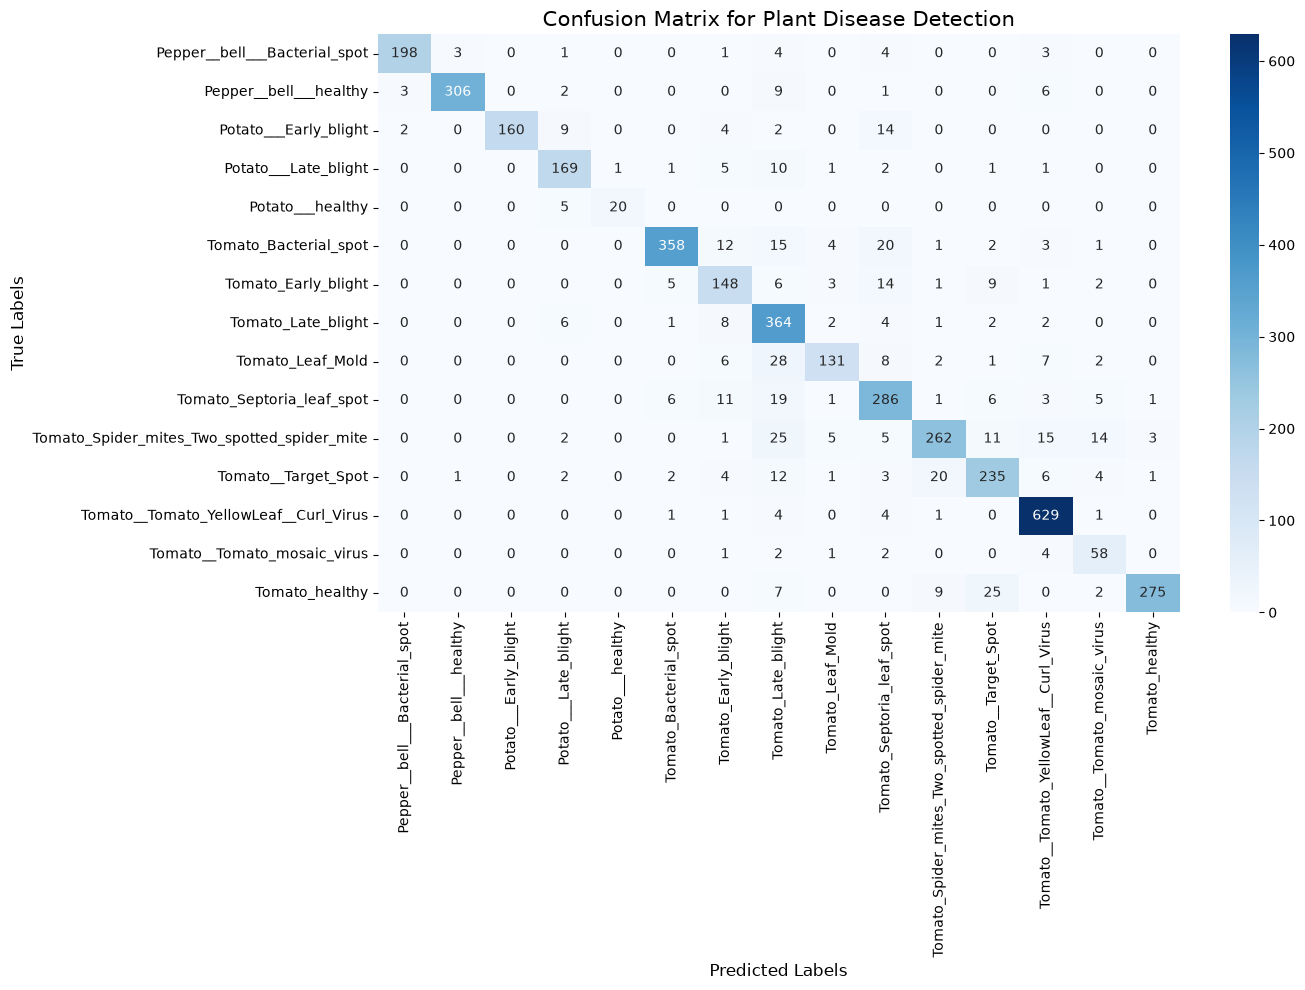

In [23]:

# 2. رسم المصفوفة
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.title('Confusion Matrix for Plant Disease Detection', fontsize=15)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [24]:

# 3. التقرير النهائي
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

Classification Report:

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      0.93      0.95       214
                     Pepper__bell___healthy       0.99      0.94      0.96       327
                      Potato___Early_blight       1.00      0.84      0.91       191
                       Potato___Late_blight       0.86      0.88      0.87       191
                           Potato___healthy       0.95      0.80      0.87        25
                      Tomato_Bacterial_spot       0.96      0.86      0.91       416
                        Tomato_Early_blight       0.73      0.78      0.76       189
                         Tomato_Late_blight       0.72      0.93      0.81       390
                           Tomato_Leaf_Mold       0.88      0.71      0.78       185
                  Tomato_Septoria_leaf_spot       0.78      0.84      0.81       339
Tomato_Spider_mites_Two_spotted_spider_m